# 📦 Notebook 01 — Load Semua Dataset & Exploratory Data Analysis
## Early Warning System Krisis Pariwisata Bali

Notebook ini berisi:
- Setup struktur folder
- Install library yang dibutuhkan
- Load semua dataset mentah
- Preview awal setiap dataset (EDA dasar)

## 1. Install Library

In [1]:
# !pip install pandas numpy matplotlib seaborn openpyxl xlrd scikit-learn langdetect
# !pip install transformers torch sentencepiece

## 2. Setup Struktur Folder

In [2]:
import os

# Buat struktur folder project
folders = [
    'data/raw',
    'data/processed',
    'data/final',
    'notebooks',
    'models',
    'src'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'✅ Created: {folder}')

print('\n📁 Struktur folder berhasil dibuat!')
print('\n⚠️  PENTING: Pindahkan semua file dataset ke folder: data/raw/')

✅ Created: data/raw
✅ Created: data/processed
✅ Created: data/final
✅ Created: notebooks
✅ Created: models
✅ Created: src

📁 Struktur folder berhasil dibuat!

⚠️  PENTING: Pindahkan semua file dataset ke folder: data/raw/


## 3. Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 4. Load Dataset
### 4.1 Gab_Data_Wisman_Bali.xlsx (Wisatawan Mancanegara Gabungan)

In [5]:
# Format: Tanggal | Banyak — sudah bersih, bulanan 2009-sekarang
wisman_gab = pd.read_excel('data/raw/Gab_Data_Wisman_Bali.xlsx')
print('Shape:', wisman_gab.shape)
print('Columns:', wisman_gab.columns.tolist())
print()
wisman_gab.head(5)

Shape: (192, 2)
Columns: ['Tanggal', 'Banyak']



,Tanggal,Banyak
0,2009-01-01,174541
1,2009-02-01,147704
2,2009-03-01,168205
3,2009-04-01,188776
4,2009-05-01,190803


### 4.2 Wisman Bulanan 1982-2008 (XLS BPS)

In [6]:
# Format wide: baris=bulan, kolom=tahun, skiprows=3
wisman_old = pd.read_excel(
    'data/raw/banyaknya-wisatawan-mancanegara-bulanan-ke-bali.xls',
    engine='xlrd',
    header=None
)
print('Shape:', wisman_old.shape)
print()
wisman_old.head(6)

Shape: (38, 15)



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,Banyaknya Wisatawan Mancanegara Bulanan ke Bal...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Number of Monthly Foreign Visitor to Bali, 198...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Bulan / Month,1982.0,1983.0,1984.0,1985.0,1986.0,1987.0,1988.0,1989.0,1990.0,1991.0,1992.0,1993.0,1994.0,1995.0
4,Januari / January,11961.0,12024.0,17062.0,14897.0,19378.0,22870.0,29251.0,31755.0,40066.0,34919.0,46877.0,75558.0,73776.0,87705.0
5,Pebruari / February,10278.0,11192.0,14038.0,16899.0,18738.0,21652.0,28207.0,32279.0,32808.0,32585.0,54384.0,58539.0,87313.0,86487.0


### 4.2b Wisman Mancanegara Bali vs Indonesia Tahunan 1969–2025


In [7]:
# Format: 2 tabel side by side (kolom 0-4 dan kolom 6-10)
# Kolom: Tahun | Indonesia Total | Indonesia Growth% | Bali Total | Bali Growth%
# Data tahunan 1969–2025 — berguna untuk fitur bali_share_pct (market share Bali)

wisman_bali_indonesia_raw = pd.read_excel(
    'data/raw/banyaknya-wisatawan-mancanegara-ke-bali-dan-indonesia.xls',
    engine='xlrd',
    header=None
)
print('Shape:', wisman_bali_indonesia_raw.shape)
print()
wisman_bali_indonesia_raw.head(8)


Shape: (36, 11)



,0,1,2,3,4,5,6,7,8,9,10
0,"Jumlah Wisatawan Asing ke Indonesia dan Bali, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Number of Foreign Visitor to Indonesia and Bal...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Tahun,Indonesia,NaN,Bali,NaN,NaN,Tahun,Indonesia,NaN,Bali,NaN
4,Year,Total,Growth (%),Total,Growth (%),NaN,Year,Total,Growth (%),Total,Growth (%)
5,1969,86067,-,11278,-,NaN,1998,4606416,-11.149996,1187153,-3.508286
6,1970,129319,50.253872,24340,115.818408,NaN,1999,4600000,-0.139284,1355799,14.20592
7,1971,178781,38.248053,34313,40.973706,NaN,2000,5064217,10.091674,1412839,4.207113


### 4.3 Wisatawan Domestik Bulanan 2004-2025

In [8]:
# Format wide: Bulan + kolom tahun 2004-2025, skiprows=3
wisnus = pd.read_excel(
    'data/raw/banyaknya-wisatawan-domestik-bulanan-ke-bali.xls',
    engine='xlrd',
    header=None
)
print('Shape:', wisnus.shape)
print()
wisnus.head(6)

Shape: (53, 10)



,0,1,2,3,4,5,6,7,8,9
0,Kunjungan Wisatawan Domestik ke Bali per Bulan...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Number of Domestic Visitor to Bali by Month, 2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Bulan,2004,2005.0,2006.0,2007.0,2008.0,2009.0,2010.0,2011.0,2012.0
4,Januari,167106,174515.0,202857.0,181266.0,225955.0,264915.0,349575.0,280588.0,333199.0
5,Pebruari,133660,161808.0,161413.0,144425.0,190792.0,204419.0,238789.0,340508.0,305934.0


### 4.4 Wisman berdasarkan Kebangsaan 2019-2024

In [9]:
wisman_kebangsaan = pd.read_excel(
    'data/raw/-banyaknya-wisatawan-mancanegara-yang-datang-langsung-ke-bali-menurut-kebangsaan-2019-2024.xlsx',
    header=None
)
print('Shape:', wisman_kebangsaan.shape)
print()
wisman_kebangsaan.head(8)

Shape: (41, 9)



,0,1,2,3,4,5,6,7,8
0,Banyaknya Wisatawan Mancanegara yang Datang La...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Number of Foreign Visitors Arriving Directly b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Kebangsaan (Negara Asal),NaN,NaN,2019,2020,2021,2022,2023,2024
4,Nationality (Country of Origin),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,I.,ASEAN,NaN,613509,100967,-,337769,699924,713315
6,NaN,1.,Malaysia / Malaysia,185256,31587,-,91064,207573,246145
7,NaN,2.,Philipina / Philippines,106875,16642,-,30427,85866,103665


### 4.5 TPK Hotel Bintang

In [11]:
# Format wide: baris=kelas hotel bintang, kolom=bulan, mulai tahun 2000
tpk_bintang = pd.read_excel(
    'data/raw/Tingkat Penghunian Kamar (TPK) Hotel Bintang.xlsx',
    header=None
)
print('Shape:', tpk_bintang.shape)
print()
tpk_bintang.head(8)

Shape: (10, 14)



,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Kelas Hotel Bintang,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Tingkat Penghunian Kamar (TPK) Hotel Bintang M...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
4,Bintang 5,56.5,59.34,58.49,62.19,61.07,68.6,70.78,71.97,73.64,75.5,70.92,58.49,64.18
5,Bintang 4,53.11,47.51,49.13,48.77,46.03,52.97,64.26,62.09,55.58,66.42,53.9,47.13,52.76
6,Bintang 3,44.41,43.55,39.68,48.55,41.2,50.48,58.12,47.82,57.67,50.35,50.3,50.79,47.68
7,Bintang 2,43.87,42.66,40.68,44.59,39.87,43.91,56.1,54.02,54.53,42.97,50.75,45.79,46.15


### 4.6 TPK Hotel Non Bintang

In [12]:
tpk_nonbintang = pd.read_excel(
    'data/raw/Tingkat Penghunian Kamar (TPK).xlsx',
    header=None
)
print('Shape:', tpk_nonbintang.shape)
print()
tpk_nonbintang.head(8)

Shape: (14, 14)



,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Kabupaten/Kota,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Tingkat Penghunian Kamar (TPK) Hotel Non Binta...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
4,Kab. Jembrana,-,17.3,19.65,19.89,21.26,20.34,17.14,17.34,26.71,24.33,29.24,21.71,-
5,Kab. Tabanan,-,26.11,17.75,14.24,16.72,8.02,8.34,14.52,22.54,25.81,31.37,23.87,-
6,Kab. Badung,-,43.4,44.15,40.45,40.09,46.29,44.2,56.39,51.5,51.5,40.32,49.17,-
7,Kab. Gianyar,-,16.83,17.26,17.21,16.53,11.95,23.88,22.25,16.44,28.39,28.31,18.53,-


### 4.7 Lama Menginap Hotel Bintang & Non Bintang

In [13]:
lama_bintang = pd.read_excel(
    'data/raw/Rata-Rata Lama Menginap Tamu Asing dan Domestik pada Hotel Bintang.xlsx',
    header=None
)
print('Lama Menginap Hotel Bintang - Shape:', lama_bintang.shape)
print()
lama_bintang.head(6)

Lama Menginap Hotel Bintang - Shape: (10, 14)



,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Kelas Hotel Bintang,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Rata-Rata Lama Menginap Tamu Asing dan Domesti...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
4,Bintang 5,4,3.9,3.9,3.6,3.5,4.1,3.7,3.7,3.9,3.9,3.9,4,3.8
5,Bintang 4,4.1,4.5,4.4,4.2,4.5,3.7,3.8,4.2,3.9,4.7,4,4,4.1


In [14]:
lama_nonbintang = pd.read_excel(
    'data/raw/Rata-Rata Lama Menginap Tamu Asing dan Domestik pada Hotel Non Bintang.xlsx',
    header=None
)
print('Lama Menginap Hotel Non Bintang - Shape:', lama_nonbintang.shape)
print()
lama_nonbintang.head(6)

Lama Menginap Hotel Non Bintang - Shape: (14, 14)



,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Kabupaten/Kota,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Rata-Rata Lama Menginap Tamu Asing dan Domesti...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
4,Kab. Jembrana,-,1.88,1.56,1.55,1.79,1.13,1.24,1.32,1.22,1.64,1.49,1.84,-
5,Kab. Tabanan,-,1.27,1.12,2.14,2.21,1.18,1.71,1.17,1.01,1.35,1.54,1.34,-


### 4.8 Inflasi Bulanan Bali 2024

In [15]:
# Format wide: baris=kota, kolom=bulan (Januari-Desember + Tahunan)
inflasi = pd.read_excel(
    'data/raw/Inflasi_Bulanan.xlsx',
    header=None
)
print('Shape:', inflasi.shape)
print()
inflasi

Shape: (10, 14)



,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Kota Inflasi (2022=100),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Inflasi Bulanan (month to month) Provinsi Bali...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
4,Kabupaten Tabanan,-0.07,0.68,0.91,0.42,-0.28,-1.09,0.09,0.28,0.26,-0.03,0.76,0.49,2.44
5,Kabupaten Badung,-0.01,0.58,1.1,0.03,-0.09,-0.63,-0.03,-0.09,0.09,-0.02,0.68,0.37,1.98
6,Singaraja,-0.22,0.51,0.89,0.07,-0.33,-0.53,0.12,-0.18,0.25,0.21,0.81,0.32,1.93
7,Kota Denpasar,-0.08,0.65,0.87,0.53,0.05,-0.32,0.16,0.26,0.06,0.1,0.19,0.19,2.69
8,Provinsi Bali,-0.09,0.61,0.93,0.32,-0.1,-0.55,0.1,0.1,0.13,0.07,0.5,0.31,2.34
9,Nasional,0.04,0.37,0.52,0.25,-0.03,-0.08,-0.18,-0.03,-0.12,0.08,0.3,0.44,1.57


### 4.9 Kurs USD/IDR Historical

In [16]:
# Format: Date | Price | Open | High | Low | Change %
usd_idr = pd.read_csv('data/raw/USD_IDR Historical Data.csv')
print('Shape:', usd_idr.shape)
print('Columns:', usd_idr.columns.tolist())
print()
usd_idr.head(5)

Shape: (3858, 6)
Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Change %']



,Date,Price,Open,High,Low,Change %
0,12/31/2024,"16,090.00","16,090.00","16,172.50","16,070.00",-0.25%
1,12/30/2024,"16,130.00","16,175.00","16,195.00","16,127.50",-0.62%
2,12/27/2024,"16,230.00","16,207.50","16,260.00","16,205.00",0.28%
3,12/26/2024,"16,185.00","16,185.00","16,185.00","16,185.00",0.00%
4,12/25/2024,"16,185.00","16,185.00","16,185.00","16,185.00",0.00%


### 4.10 Daily Forex Rates (Multi Currency)

In [17]:
# Format: currency | base_currency | currency_name | exchange_rate | date
forex = pd.read_csv('data/raw/daily_forex_rates.csv')
print('Shape:', forex.shape)
print('Columns:', forex.columns.tolist())
print('Currency tersedia (sample):', forex['currency'].unique()[:20].tolist())
print()
# Filter IDR saja
idr_forex = forex[forex['currency'] == 'IDR']
print('IDR rows:', len(idr_forex))
idr_forex.head(5)

Shape: (481415, 5)
Columns: ['currency', 'base_currency', 'currency_name', 'exchange_rate', 'date']
Currency tersedia (sample): ['ZWL', 'GHS', 'HRK', 'HNL', 'HKD', 'GYD', 'GTQ', 'GNF', 'GMD', 'GIP', 'GGP', 'HUF', 'GEL', 'GBP', 'FKP', 'FJD', 'EUR', 'ETB', 'ERN', 'EGP']

IDR rows: 3263


,currency,base_currency,currency_name,exchange_rate,date
21,IDR,EUR,Indonesian Rupiah,20550.940804,2026-05-21
238,IDR,EUR,Indonesian Rupiah,20515.495997,2026-05-20
350,IDR,EUR,Indonesian Rupiah,20634.394932,2026-05-19
607,IDR,EUR,Indonesian Rupiah,20550.645714,2026-05-18
738,IDR,EUR,Indonesian Rupiah,20458.933129,2026-05-17


### 4.11 Bali Hotel Review.csv

In [18]:
# Format: semicolon-separated, kolom: Location;Hotel;UserID;Title;Review;Rating;Value;Accessibility;Service;Room;Cleanliness;Sleep Quality
hotel_reviews = pd.read_csv(
    'data/raw/Bali Hotel Review.csv',
    sep=';',
    engine='python',
    on_bad_lines='skip'
)
print('Shape:', hotel_reviews.shape)
print('Columns:', hotel_reviews.columns.tolist())
print()
hotel_reviews.head(3)

Shape: (5798, 12)
Columns: ['Location', 'Hotel', 'UserID', 'Title', 'Review', 'Rating', 'Value', 'Accessibility', 'Service', 'Room', 'Cleanliness', 'Sleep Quality']



,Location,Hotel,UserID,Title,Review,Rating,Value,Accessibility,Service,Room,Cleanliness,Sleep Quality
0,Legian Kuta Bali,Merccure Bali Legian,Barry Sloan,Nice Hotek,Check in was smooth although my room wasn’t re...,4,0.0,0.0,1.0,0.0,0.0,0.0
1,Legian Kuta Bali,Merccure Bali Legian,u4ianoosa,"Perfect location, great Facilities",We thoroughly enjoyed our stay at Mercure Legi...,5,0.0,0.0,1.0,1.0,0.0,0.0
2,Legian Kuta Bali,Merccure Bali Legian,Phoenix G,A Fortnight at Mercure Legian Bali,Really the rating is 4.7 (I will attempt to ma...,5,0.0,1.0,1.0,0.0,0.0,0.0


### 4.12 Dataset of Digital Reviews in Tourism

In [19]:
# Format: hanya satu kolom 'review'
digital_reviews = pd.read_csv(
    'data/raw/Dataset of Digital Reviews in Tourism - 2.csv',
    engine='python',
    on_bad_lines='skip'
)
print('Shape:', digital_reviews.shape)
print('Columns:', digital_reviews.columns.tolist())
print()
digital_reviews.head(3)

Shape: (56448, 1)
Columns: ['review']



,review
0,An out of this world experience! Gita was an a...
1,What an amazing experience. Not only Orang-uta...
2,Good experience with the friendly staff at the...


## 5. Ringkasan Semua Dataset

In [20]:
summary = {
    'Dataset': [
        'Gab_Data_Wisman_Bali',
        'Wisman Bulanan (lama)',
        'Wisman Bali vs Indonesia Tahunan',
        'Wisnus Bulanan',
        'Wisman per Kebangsaan',
        'TPK Hotel Bintang',
        'TPK Hotel Non Bintang',
        'Lama Menginap Bintang',
        'Lama Menginap Non Bintang',
        'Inflasi Bulanan',
        'USD/IDR Historical',
        'Daily Forex Rates',
        'Bali Hotel Review',
        'Digital Reviews Tourism'
    ],
    'Tipe': [
        'Time Series', 'Time Series', 'Time Series', 'Time Series', 'Cross Section',
        'Time Series', 'Time Series', 'Time Series', 'Time Series',
        'Time Series', 'Time Series', 'Time Series', 'NLP', 'NLP'
    ],
    'Kelompok': [
        'Tourism Indicator', 'Tourism Indicator', 'Tourism Indicator', 'Tourism Indicator', 'Tourism Indicator',
        'Tourism Indicator', 'Tourism Indicator', 'Tourism Indicator', 'Tourism Indicator',
        'Economic Indicator', 'Economic Indicator', 'Economic Indicator',
        'Sentiment Data', 'Sentiment Data'
    ]
}

summary_df = pd.DataFrame(summary)
print('=== RINGKASAN DATASET ===')
print(summary_df.to_string(index=False))

=== RINGKASAN DATASET ===
                         Dataset          Tipe           Kelompok
            Gab_Data_Wisman_Bali   Time Series  Tourism Indicator
           Wisman Bulanan (lama)   Time Series  Tourism Indicator
Wisman Bali vs Indonesia Tahunan   Time Series  Tourism Indicator
                  Wisnus Bulanan   Time Series  Tourism Indicator
           Wisman per Kebangsaan Cross Section  Tourism Indicator
               TPK Hotel Bintang   Time Series  Tourism Indicator
           TPK Hotel Non Bintang   Time Series  Tourism Indicator
           Lama Menginap Bintang   Time Series  Tourism Indicator
       Lama Menginap Non Bintang   Time Series  Tourism Indicator
                 Inflasi Bulanan   Time Series Economic Indicator
              USD/IDR Historical   Time Series Economic Indicator
               Daily Forex Rates   Time Series Economic Indicator
               Bali Hotel Review           NLP     Sentiment Data
         Digital Reviews Tourism           NLP    

## 6. Visualisasi Awal — Tren Wisman (EDA)

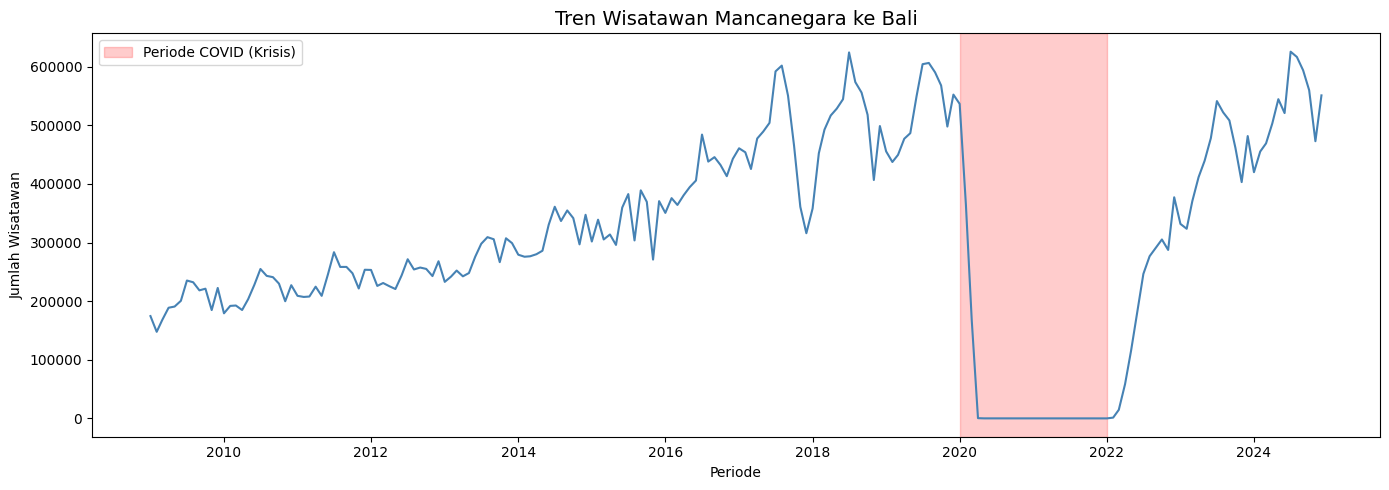

✅ Plot disimpan ke data/processed/eda_wisman_trend.png


In [21]:
# Quick plot wisman gabungan
wisman_plot = wisman_gab.copy()
wisman_plot.columns = ['date', 'wisman']
wisman_plot['date'] = pd.to_datetime(wisman_plot['date'])
wisman_plot = wisman_plot.sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(wisman_plot['date'], wisman_plot['wisman'], color='steelblue', linewidth=1.5)
plt.axvspan(pd.to_datetime('2020-01-01'), pd.to_datetime('2021-12-31'),
            alpha=0.2, color='red', label='Periode COVID (Krisis)')
plt.title('Tren Wisatawan Mancanegara ke Bali', fontsize=14)
plt.xlabel('Periode')
plt.ylabel('Jumlah Wisatawan')
plt.legend()
plt.tight_layout()
plt.savefig('data/processed/eda_wisman_trend.png', dpi=150)
plt.show()
print('✅ Plot disimpan ke data/processed/eda_wisman_trend.png')